<h1 style="font-size: 300%; font-weight: 100"><span style="font-size: 60%">Part 2:</span><br>$Z\rightarrow ee$ calorimeter calibration</h1>

In Part 3 of the ATLAS FP experiemnt, the W mass measuremnt, we will need pricise
energy measurements from the calorimeter of the ATLAS detector. However,
the response of the detectors differs from module to module in differnt regions
of the detector. A major cause of this effect is the unequally distributed
material between the interaction point and the detector modules, see Fig. 3.3 in
the instructions.

In this part we want to callibrate the calorimeter by using real data of
$Z\rightarrow ee$ events. The mass of the $Z$ boson has been measured to high
precision at LEP. We can compute the correction factors

$$
\alpha = \frac{E_{\mathrm{meas}}}{E_{\mathrm{true}}} - 1
$$

by fitting a Breit-Wigner to the invariant mass $m_{ee}$ distribution.

<div style="border: 1px solid black; padding: 1em">
    About this notebook: Tasks are marked with <b>Assignemnt</b>, places where
    you need to add code are marked with <code># TODO</code>.
</div>

In [1]:
#Running for the first time you might have to install additional packages (please uncomment line below)
# %pip install -r requirements.txt

In [2]:
from glob import glob

import uproot as up
import numpy as np
import matplotlib.pyplot as plt
from pylorentz import Momentum4
from atlasify import atlasify

import ROOT
print(ROOT.gROOT.GetVersion()) 
import fputils as fpu

6.38.02


In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Let's make sure we have a directory where we want to dump plots to
%mkdir -p plots

# 1. Getting to know the data
The data for this part is located in the directory `data`.

In [5]:
!ls "data/"

ls: cannot access 'data/': No such file or directory


The directory contains real measured data (starting with `v5.data11_7TeV`) and
simulated events (starting with `v5.mc11_7TeV`).

In [6]:
data_paths = sorted(glob("/home/cl313/test/ATLAS/data/data/v5.data11_7TeV.*.root"))
mc_paths = sorted(glob("/home/cl313/test/ATLAS/data/data/v5.mc11_7TeV.*.root"))

The events are stored in a
TTree object called `eventTree` inside the ROOT files. A TTree can be thought of as a table. Each
event occupies one line in the table. The columns are named and contain
different properties of the events, for example, 

 - `el_n` is the number of electrons in the event,
 - `el1_cl_eta` is the eta coordinate of the first electron,
 - `el2_cl_phi` is the phi coordinate of the second electron and
 - `el2_cl_E` is the energy of the second electron in MeV.
 
ROOT files and in particular TTrees are tradionally opened and processed with
ROOT. In this notebook we will open them with `uproot` which returns the data
in a neat Pandas DataFrame.

In [7]:
# /home/cl313/test/ATLAS/atlas-group-7-main/atlas-group-7-main/ZeeFit/data/data

root_file = up.open("/home/cl313/test/ATLAS/data/data/v5.data11_7TeV.periodF.physics_Egamma.grp10_v01_p1035.root")
ttree = root_file["eventTree"]
dataframe = ttree.arrays(library='pd')
# dataframe['el1_cl_E']*=1e-6
# dataframe['el2_cl_E']*=1e-6

**Assignment:** Inspect the DataFrame and see which quantities are stored.

In [8]:
dataframe

,RunNumber,el_n,el1_cl_E,el1_cl_eta,el1_cl_phi,el1_charge,el1_isMediumPP,el1_isTightPP,el1_isolation,el2_cl_E,...,el2_isMediumPP,el2_isTightPP,el2_isolation,MET,MET_phi,MET_sumEt,jet_n,EF_e20_medium,EF_e22_medium,EF_e22vh_medium1
0,182013,1,187745.843750,-2.416714,0.428330,-1,True,False,0.011033,-999.0,...,False,False,-999.0,5338.998047,0.814943,161127.125000,1.0,True,True,False
1,182013,1,179066.968750,-2.355452,2.004849,-1,True,True,0.073835,-999.0,...,False,False,-999.0,54589.664062,-1.646896,145482.656250,1.0,True,True,False
2,182013,1,36398.062500,-0.604873,1.933393,1,True,True,0.024660,-999.0,...,False,False,-999.0,37429.632812,-1.750604,144790.968750,0.0,True,True,False
3,182013,1,214604.687500,2.001213,0.633456,1,True,True,0.006124,-999.0,...,False,False,-999.0,28836.958984,-2.725142,259332.375000,1.0,True,True,False
4,182013,1,154882.546875,2.365343,0.732619,1,True,False,0.160881,-999.0,...,False,False,-999.0,10147.016602,0.965020,270285.031250,1.0,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1653012,182519,1,31145.767578,-0.206962,-0.569484,1,True,True,0.004780,-999.0,...,False,False,-999.0,25795.031250,3.130959,251983.140625,0.0,True,True,False
1653013,182519,1,79373.789062,1.888792,2.087517,1,True,False,0.094324,-999.0,...,False,False,-999.0,20112.722656,0.353965,297106.906250,1.0,True,True,False
1653014,182519,1,35922.187500,0.444454,-2.067250,1,True,True,-0.026270,-999.0,...,False,False,-999.0,33826.359375,0.953537,276430.656250,0.0,True,True,False
1653015,182519,1,37537.871094,1.044812,-2.192633,1,True,False,-0.048908,-999.0,...,False,False,-999.0,15767.332031,1.292546,336063.625000,0.0,True,True,False


In [9]:
dataframe.columns

Index(['RunNumber', 'el_n', 'el1_cl_E', 'el1_cl_eta', 'el1_cl_phi',
       'el1_charge', 'el1_isMediumPP', 'el1_isTightPP', 'el1_isolation',
       'el2_cl_E', 'el2_cl_eta', 'el2_cl_phi', 'el2_charge', 'el2_isMediumPP',
       'el2_isTightPP', 'el2_isolation', 'MET', 'MET_phi', 'MET_sumEt',
       'jet_n', 'EF_e20_medium', 'EF_e22_medium', 'EF_e22vh_medium1'],
      dtype='str')

Looking at the raw numbers does not tell you the full picture. To get a deeper
insight, it is often useful to visualize the data in a histogram. We can iterate
over all data files in small chunks with the helper function
`fpu.dataframe_iterate`. To fill a ROOT `TH1F` histogram with the data from a
DataFrame, we should use the helper function `fpu.fill_histo`. Manaully looping
over the events from Python would be too slow.

In [10]:
# 35 equidistant bins, centered around from -3.5 to 3.5
hist_el1_phi = ROOT.TH1F("", "Electron 1", 35, -3.5, 3.5)  # for electron 1
hist_el2_phi = ROOT.TH1F("", "Electron 2", 35, -3.5, 3.5)  # for electron 2

# Loop over chunks of data
for df in fpu.dataframe_iterate(data_paths, fraction=0.1):

    # df.count
    # Performant way of iterating over all events in DataFrame
    fpu.fill_histo(df.el1_cl_phi, hist_el1_phi)
    fpu.fill_histo(df.el2_cl_phi, hist_el2_phi)
    
    # Here, we could fill more histograms, compute other quantities based on
    # existing columns in the DataFrame or select only a subset of the events.
    # You can work with columns from the dataset as if it was just a single
    # value. Suitable math functions (sin, log, sqrt) are located in the numpy
    # package.
    
    # We will use this kind of loop throughout this notebook.
    
    # Please mind that for development & debugging you might use fraction of events (<1.0) to gain speed,
    # ultimately, though, you should run with fraction=1.0 (all data available)

After all the events have been processed we can visualize the histogram using ROOT's build-in tools.

In [11]:
c = ROOT.TCanvas()  # TCanvas is a container for one or more plots

# Setting axis labels
hist_el1_phi.GetXaxis().SetTitle("#phi")
hist_el1_phi.GetYaxis().SetTitle("Events / 0.2")

hist_el1_phi.Draw()  # Search for 'TH1F Draw' to see possible drawing options

hist_el2_phi.SetLineColor(ROOT.kRed)
hist_el2_phi.Draw("SAME")

c.Draw()

Alternatively, we can fall back to native Python libraries such as matplotlib.
The helper methods `fpu.hist_stack` and `fpu.hist_line` accept a single or
multiple ROOT histograms and plots them. The *stack* version stacks the event
counts such that the top line per bin is the sum of all histograms.
The *line* version draws multiple distributions in a single plot independently.

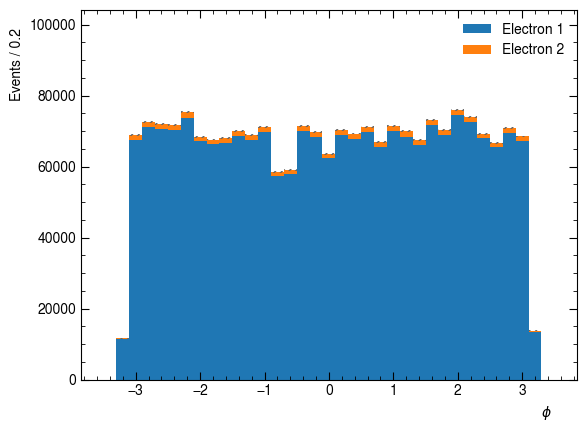

In [12]:
fpu.hist_stack(hist_el1_phi, hist_el2_phi)

# Setting axes labels
plt.xlabel(r"$\phi$", ha='right', x=0.95)
plt.ylabel("Events / 0.2", ha='right', y=0.95)

# Applying common ATLAS style.
# Make sure you ALWAYS supply 'False' as the first argument!
atlasify(False)

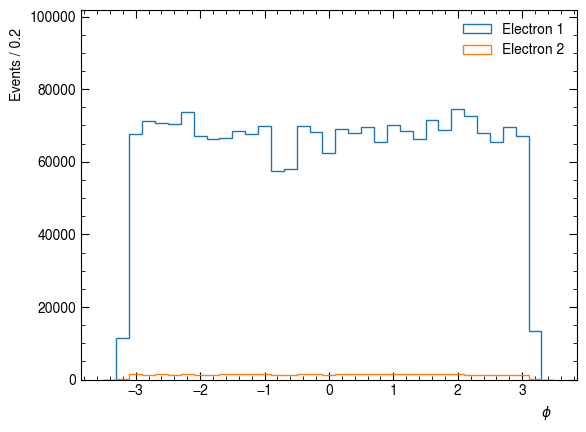

In [13]:
axes = fpu.hist_line(hist_el1_phi)
fpu.hist_line(hist_el2_phi, axes=axes)  # Draw into save axes

# Setting axes labels
plt.xlabel(r"$\phi$", ha='right', x=0.95)
plt.ylabel("Events / 0.2", ha='right', y=0.95)

# Applying common ATLAS style.
# Make sure you ALWAYS supply 'False' as the first argument!
atlasify(False)

Why fpu.dataframe_iterate function returned results in `debug mode`?

For quick checks, for example, to see whether your code works, you can 
call `fpu.dataframe_iterate` with the additional `fraction` option where 
you specify what fraction of events to keep. If you remove this option, or
specify `fraction=1` all events will be loaded and this should be used
for your final plots.

**Assignment:** Have a deeper look at the dataset by plotting differnet quantities.

In [14]:
# TODO

# 35 equidistant bins, centered around from -3.5 to 3.5
hist_el1_phi = ROOT.TH1F("", "Electron 1", 35, -3.5, 3.5)  # for electron 1
hist_el2_phi = ROOT.TH1F("", "Electron 2", 35, -3.5, 3.5)  # for electron 2

# Loop over chunks of data
for df in fpu.dataframe_iterate(data_paths, fraction=0.1):

    # df.count
    # Performant way of iterating over all events in DataFrame
    fpu.fill_histo(df.el2_isolation, hist_el1_phi)
    fpu.fill_histo(df.el1_isolation, hist_el2_phi)

c = ROOT.TCanvas()  # TCanvas is a container for one or more plots

# Setting axis labels
hist_el1_phi.GetXaxis().SetTitle("#isolation")
hist_el1_phi.GetYaxis().SetTitle("Events / 0.2")

hist_el1_phi.Draw()  # Search for 'TH1F Draw' to see possible drawing options

hist_el2_phi.SetLineColor(ROOT.kRed)
hist_el2_phi.Draw("SAME")

c.Draw()


In [15]:
c = ROOT.TCanvas()  # TCanvas is a container for one or more plots

# Setting axis labels
hist_el1_phi.GetXaxis().SetTitle("#isolation")
hist_el1_phi.GetYaxis().SetTitle("Events / 0.2")

hist_el1_phi.Draw()  # Search for 'TH1F Draw' to see possible drawing options

hist_el2_phi.SetLineColor(ROOT.kRed)
hist_el2_phi.Draw("SAME")

c.Draw()

# 2. Selecting events

The dataset with real data events contain events with at least one electron with
$p_\mathrm{T} > 25\,\mathrm{Ge\kern-0.1em V}$.
The events in the dataset stem from mixture of different physics processes. For
the calibration, we want to select events which originate from $Z\rightarrow ee$
decays and discard events, for example, from $W\rightarrow e \nu$.

**Assignment:** What criteria are suitable to select event originating from $Z\rightarrow ee$ while at the same time reject $W\rightarrow e \nu$. Especially, think about
  - number of electrons,
  - isolation of the electrons,
  - tight and medium identification working points and
  - charge of the electrons.
  
 What is the *isolation* and the *identification working point*?
 
**Assignment:** Apply these criteria to the events and document the cuts at every stage.

In [16]:
# We need exactly two electrons in the event
hist_el_n = ROOT.TH1F("", "Number of electrons", 4, -0.5, 3.5)

# TODO: add another histograms for other variables and for different selection steps

In [17]:
for df in fpu.dataframe_iterate(data_paths,fraction=0.1):

    df = df[df.el_n==2] # Keep only events with two electrons
    df = df[df.el1_isTightPP]
    df = df[df.el2_isTightPP]
    # df = df[df.el1_isolation>0.4]
    # df = df[df.el2_isolation>0.4]
    df = df[df.el1_charge == -df.el2_charge]

    fpu.fill_histo(df.el_n, hist_el_n)  # Fill histogram with number of events
    
    # TODO: add more cuts


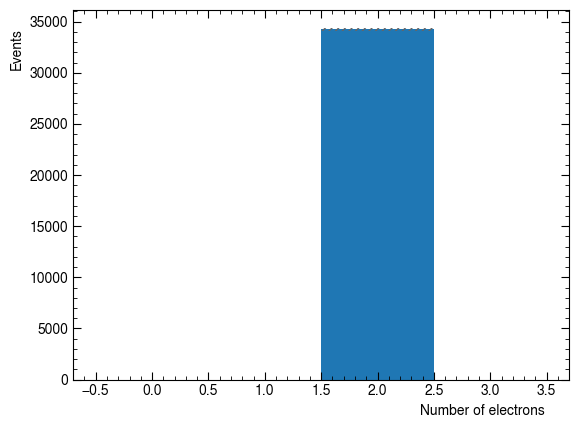

In [18]:
fpu.hist_stack(hist_el_n)
plt.xlabel("Number of electrons", ha='right', x=0.95)
plt.ylabel("Events", ha='right', y=0.95)
atlasify(False, enlarge=1)
plt.savefig("plots/n_el.pdf")

In [19]:
# TODO: plot and save

**Assignment:** Complete the implementation of `event_selection()` with the cuts you have worked out.

In [20]:
def event_selection(df):
    """
    Returns a new DataFrame with only a subset of events, selected for the
    analysis.
    """
    # Keep only events with two electrons
    df = df[df.el_n == 2]
    df = df[df.el1_isTightPP]
    df = df[df.el2_isTightPP]
    df = df[abs(df.el1_isolation)<0.1]
    df = df[abs(df.el2_isolation)<0.1]
    df = df[df.el1_charge == -df.el2_charge]

    # TODO: Add your final selection here
    
    return df

# 3. $m_{ee}$ in different $\eta$-bins

## Plot $m_{ee}$

Relativistic kinematics tells us how to compute the invarient mass of the $ee$
system and thus the rest mass of the $Z$. In the dataset we have $\phi$, $\eta$,
$E$ of each electron. The electron mass is also known. The library `pylorentz`
and its `Momentum4` class helps us to compute the invarent mass of the system.

In [21]:
help(Momentum4.m_eta_phi_pt)

Help on function m_eta_phi_pt in module pylorentz:

m_eta_phi_pt(m, eta, phi, p_t)
    Creates a new energy-momentum vector based on mass, pseudo-rapidity,
    polar angle and transverse momentum.



**Assignment:** How can we compute the transverse momentum based on the information in the dataset?

In [22]:
def pt(E, eta, m_e):  

    return np.sqrt(E**2-m_e**2) / np.cosh(eta) # TODO: Actually compute p_T

Once we have the 4-momenta of both electrons, say `e1_p4` and `e2_p4`, we can add them an retrieve the
invariant mass of the di-electron system:

```python
mee = (e1_p4 + e2_p4).m
```

The method `Momentum4.m_eta_phi_pt` accecpts arrays from a DataFrame and
transparently hides the loop over the individual events, i.e., it behaves like
any other numpy function.

In [23]:
# Preview of Particle Physics, M. Tanabashi et al., Phys. Rev. D 98, 030001
m_e = 0.5109989461 #mev

In [24]:
hist_mee = ROOT.TH1F("", "mee", 150, 30, 120)

for df in fpu.dataframe_iterate(data_paths,fraction=.2):
    # Apply the event selection from the previous section
    df = event_selection(df)
    print(np.mean(df.el1_isolation), np.mean(df.el2_isolation))
    # Compute pT
    e1_pt = pt(df.el1_cl_E, df.el1_cl_eta, m_e)
    e2_pt = pt(df.el2_cl_E, df.el2_cl_eta, m_e)
    
    # Construct 4-momenta
    e1_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el1_cl_eta,
                                   df.el1_cl_phi,
                                   e1_pt)
    e2_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el2_cl_eta,
                                   df.el2_cl_phi,
                                   e2_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mee = (e1_p4 + e2_p4).m 
    mee *= 1e-3 # Conversion from MeV to GeV

    print(np.mean(mee))

    fpu.fill_histo(mee, hist_mee)

0.004614951 0.006951122
83.11718773450791
-0.004107891 -0.0020581377
83.29750636704911
0.0017091418 0.0040724673
83.13621919136143
0.002120057 0.0035372525
83.29094220551421
0.0020294872 0.004511031
83.19319447983665
0.009115829 0.011593436
83.60034042722602
-0.0014509389 -0.001128747
83.75667235388629


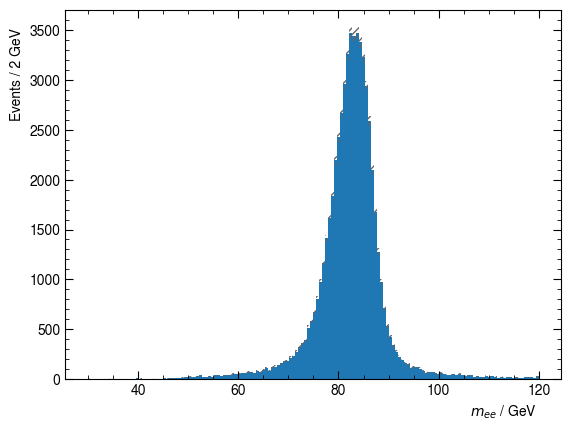

In [25]:
fpu.hist_stack(hist_mee)
plt.xlabel("$m_{ee}$ / GeV", ha='right', x=0.95)
plt.ylabel("Events / 2 GeV", ha='right', y=0.95)
atlasify(False, enlarge=1)
plt.savefig("plots/m_ee.pdf")

## $\eta$-binning

**Assignment:** Have a look at the $\eta$ distribution of you electrons. What
    happens at $\eta \approx 1.5$? 

Since the material in front of the detector hightly depends on $\eta$, we want
to compute the calibration factor $\alpha$ as a function fo $\eta$.

**Assignment:** Based on the $\eta$-distribution and Fig. 3.3, define suitable
$\eta$ bins for which we will compute the calibration factor $\alpha$.

In [26]:
eta_edges = [0,0.1,0.2,0.65,0.8,1.25,1.45,1.7,1.8,2.05,2.15,2.3,2.4,2.6]#np.linspace(0,2.5,10)#[0, 0.7, 1.37, 1.56, 2.2, 2.5] # Example value
print(eta_edges)


[0, 0.1, 0.2, 0.65, 0.8, 1.25, 1.45, 1.7, 1.8, 2.05, 2.15, 2.3, 2.4, 2.6]


In [27]:
# Create one m_ee histogram for each eta bin
hist_mee_array = [ROOT.TH1F("", fr"${eta_edges[i]:.2f} \leq |\eta| < {eta_edges[i+1]:.2f}$", 80, 60, 120)
                  for i in range(len(eta_edges) - 1)]

for df in fpu.dataframe_iterate(data_paths,fraction=1):
    # Apply the event selection from the previous section
    df = event_selection(df)
    
    # Compute pT
    e1_pt = pt(df.el1_cl_E, df.el1_cl_eta, m_e)
    e2_pt = pt(df.el2_cl_E, df.el2_cl_eta, m_e)
    
    # Construct 4-momenta
    e1_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el1_cl_eta,
                                   df.el1_cl_phi,
                                   e1_pt)
    e2_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el2_cl_eta,
                                   df.el2_cl_phi,
                                   e2_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mee = (e1_p4 + e2_p4).m 
    mee /= 1000  # Conversion from MeV to GeV
    
    # Now we need to fill the m_ee values into the appropriate histogram in
    # hist_mee_array.
    
    # The following two lines compute the bin index of every electron based on
    # the bin edges defined in eta_edges. Have a look at the documenation of
    # np.searchsorted. This is very performant compared to looping over the
    # events manually.
    el1_eta_idx = np.searchsorted(eta_edges, df.el1_cl_eta.abs()) - 1
    el2_eta_idx = np.searchsorted(eta_edges, df.el2_cl_eta.abs()) - 1
    
    # Loop over eta bins, o(10)
    for idx, h in enumerate(hist_mee_array):
        # With this step we select all events where electron 1 belongs to the
        # current eta bin, and then fill the m_ee values into the appropriate
        # histogram.
        sel = (el1_eta_idx == idx)
        fpu.fill_histo(mee[sel], h)

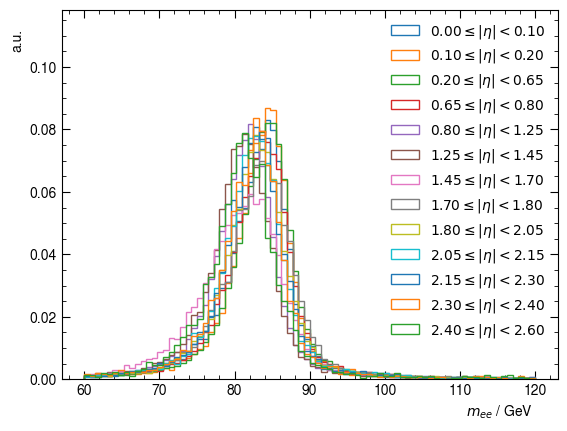

In [28]:
fig, axes = plt.subplots()
# Normalize histograms
for h in hist_mee_array:
    if(h.Integral()>0.):
        h.Scale(1 / h.Integral())
    else:
        print(h.GetTitle(), 'has no events!')
    fpu.hist_line(h, axes=axes)
    
plt.xlabel("$m_{ee}$ / GeV", ha='right', x=0.95)
plt.ylabel("a.u.", ha='right', y=0.95)
atlasify(False)
plt.savefig("plots/m_ee_binned.pdf")

# 4. Computing calibration
In each $\eta$-bin we want to fit a signal and background model. As explained in
the instructions, the signal is modelled by a convolution of a Breit-Wigner
distribution and the Crystal Ball function. The background is modelled by a
exponentionally falling sepectrum. The model is implemented using RooFit.

The fitting routine is provided via the `fpu.ZeeModel` class. The constructor of
the class expects the $m_{ee}$ histogram and the fit range. The method
`fit_to_data()` executes the actual fit and returns the mean value of the
Breit-Wigner.

In [29]:
model = fpu.ZeeModel(hist_mee_array[0], 0, 200)  # Considers all bins between 0 and 200
mean = model.fit_to_data()
# Check printout for errors

[#1] INFO:DataHandling -- RooDataHist::adjustBinning(data): fit range of variable x expanded to nearest bin boundaries: [0,200] --> [60,120]
[#0] WARNING:InputArguments -- The parameter 'widthBW' with range [0, 10] of the RooBreitWigner 'BreitWigner' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:Caching -- Changing internal binning of variable 'x' in FFT 'ZeeModel' from 100 to 930 to improve the precision of the numerical FFT. This can be done manually by setting an additional binning named 'cache'.
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'refrange_fft_ZeeModel' created with bounds [60,120]
[#1] INFO:Caching -- RooAbsCachedPdf::getCache(ZeeModel) creating new cache 0x6463ad32c0f0 with pdf BreitWigner_CONV_CBshape_CACHE_Obs[x]_NORM_x for nset (x) with code 0
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing normalization set for coeff

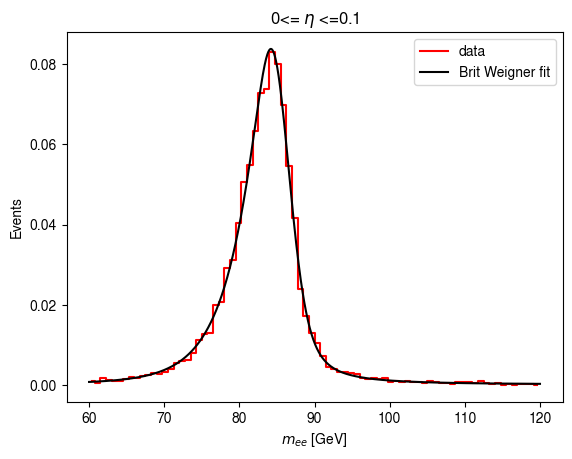

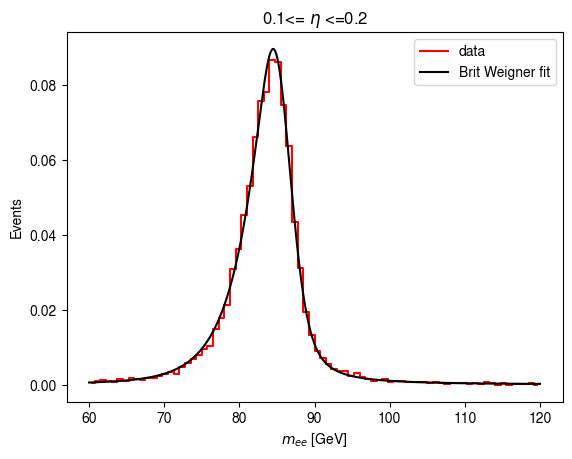

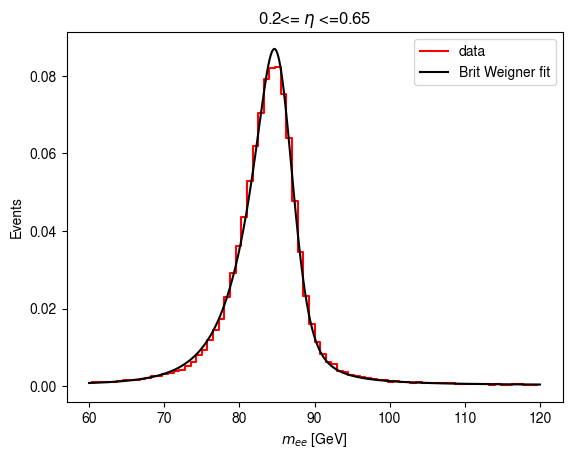

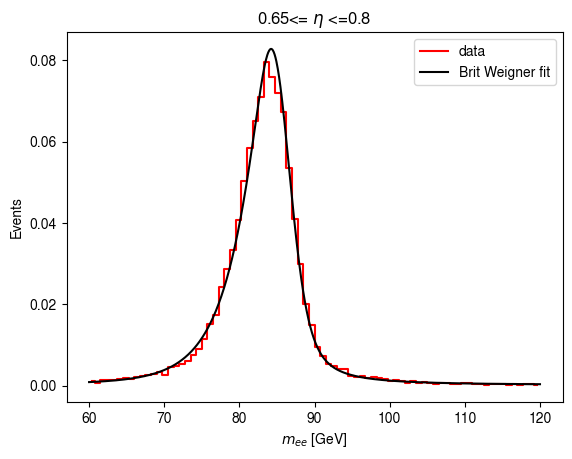

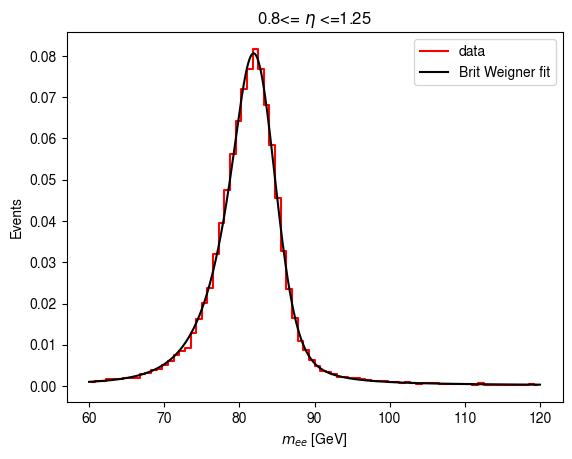

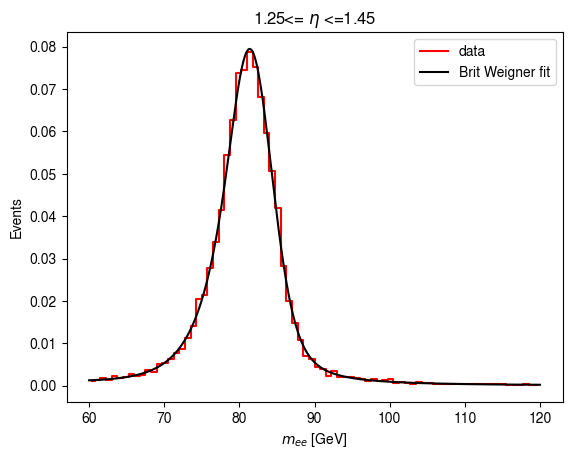

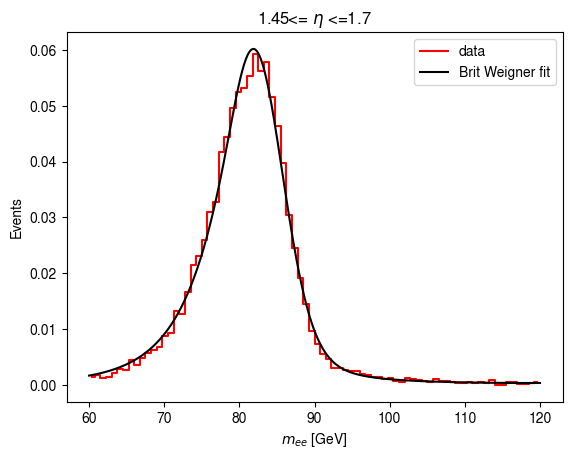

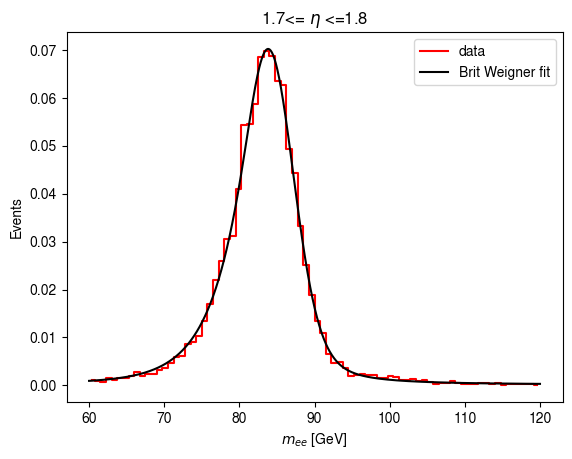

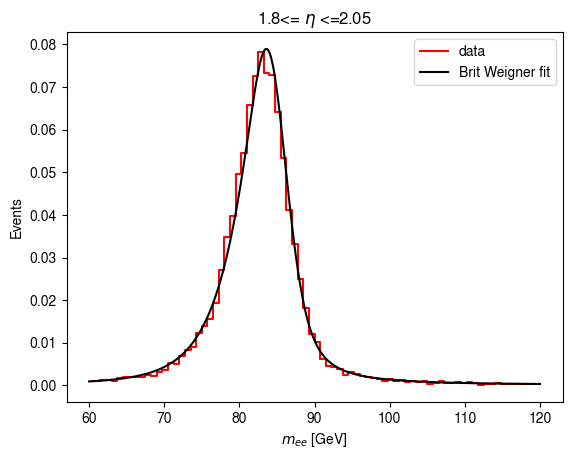

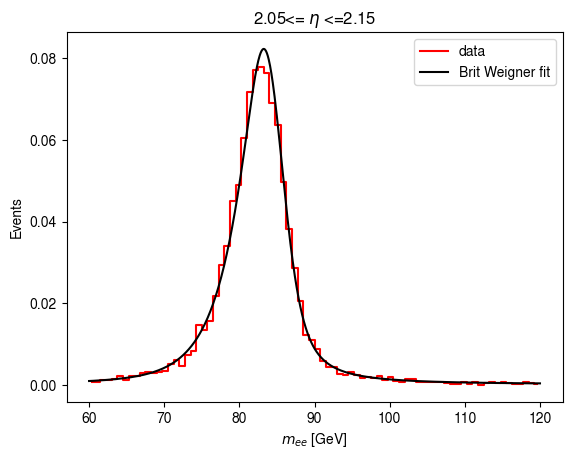

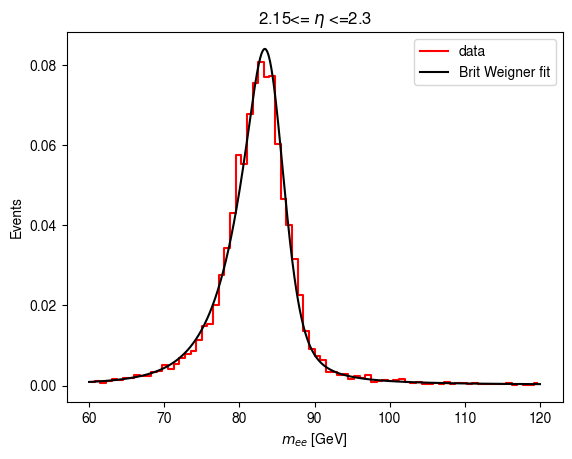

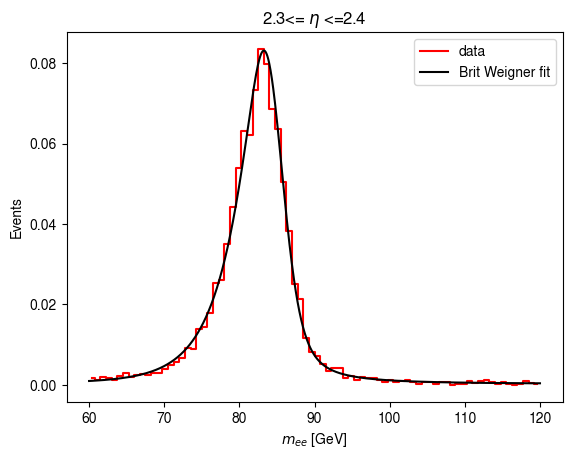

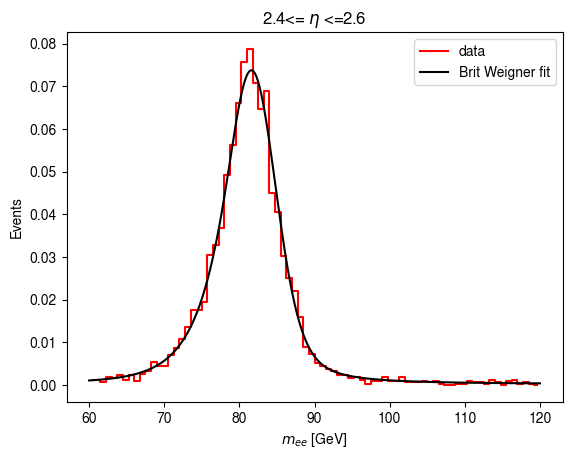

[#1] INFO:DataHandling -- RooDataHist::adjustBinning(data): fit range of variable x expanded to nearest bin boundaries: [0,200] --> [60,120]
[#0] WARNING:InputArguments -- The parameter 'widthBW' with range [0, 10] of the RooBreitWigner 'BreitWigner' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:Caching -- Changing internal binning of variable 'x' in FFT 'ZeeModel' from 100 to 930 to improve the precision of the numerical FFT. This can be done manually by setting an additional binning named 'cache'.
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'refrange_fft_ZeeModel' created with bounds [60,120]
[#1] INFO:Caching -- RooAbsCachedPdf::getCache(ZeeModel) creating new cache 0x6463af754510 with pdf BreitWigner_CONV_CBshape_CACHE_Obs[x]_NORM_x for nset (x) with code 0 from preexisting content.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing n

In [30]:
Em= []
d_Em = []

for i, hist in enumerate(hist_mee_array):
    n_bins = hist.GetNbinsX()

    model = fpu.ZeeModel(hist, 0, 200)
    res = model.fit_to_data()
    params = model.model.getParameters(model.data)

    param_dict = {}

    for var in params: 
        param_dict[var.GetName()] = {
            "value": var.getVal(),
            "error": var.getError(),
        }
    param_list = []
    for name, info in param_dict.items():
        if name == "meanBW":
            Em.append( info['value'])
            d_Em.append( info['error']) 
        
        param_list.append([name, info['value'], info['error']])

    param_array = np.array(param_list, dtype=object)
    np.savetxt("fit_params"+str(round(eta_edges[i],2))+".txt", param_array, fmt="%s", header="name value error constant", comments='')

    bin_centers = []
    bin_contents = []

    for b in range(1, n_bins + 1):
        bin_centers.append(hist.GetBinCenter(b))
        bin_contents.append(hist.GetBinContent(b))

    bin_centers = np.array(bin_centers)
    bin_contents = np.array(bin_contents)

    x_vals = np.linspace(60, 120, 1000)
    y_vals = []

    for x in x_vals:
        model.x.setVal(x)
        y_vals.append(model.model.getVal(ROOT.RooArgSet(model.x)))

    y_vals = np.array(y_vals)

    y_vals *= sum(bin_contents) * (bin_centers[1] - bin_centers[0])

    plt.figure()

    plt.step(bin_centers, bin_contents, where='mid', label='data', color='red')
    plt.plot(x_vals, y_vals, label="Brit Weigner fit", color='black')

    plt.title(str(round(eta_edges[i],2))+r'<= $\eta$ <='+ str(round(eta_edges[i+1],2)))
    plt.xlabel(r"$m_{ee}$ [GeV]")
    plt.ylabel("Events")
    plt.legend()

    plt.show()


**Assignment:** Define a suitable fitting range.

**Assignment:** Perform the fit in every $\eta$ bin.

**Assignment:** Compute the $\alpha$ values, visualize them and store them in a
file (root, npy, json or ...)

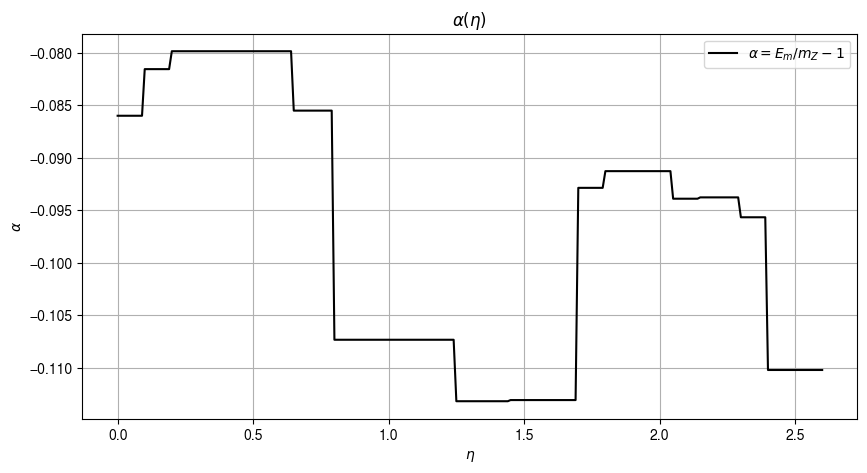

In [ ]:
# Preview of Particle Physics, M. Tanabashi et al., Phys. Rev. D 98, 030001
m_Z = 91.1876

# TODO: Compute alpha


alpha = np.array(Em)/m_Z-1  
eta_edges = [0,0.1,0.2,0.65,0.8,1.25,1.45,1.7,1.8,2.05,2.15,2.3,2.4,2.6]

eta_fine = np.arange(0, 2.6 + 0.01, 0.01) 

indices = np.digitize(eta_fine, eta_edges) - 1 
indices[indices < 0] = 0      
indices[indices >= len(alpha)] = len(alpha) - 1  

alpha_fine = alpha[indices]


plt.figure(figsize=(10,5))
plt.plot(eta_fine, alpha_fine, label=r'$\alpha = E_m/m_Z - 1$', color='black')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\alpha$')
plt.title(r'$\alpha(\eta)$')
plt.grid(True)
plt.legend()
plt.show()

np.savetxt("alpha_eta.txt", np.column_stack((eta_fine, alpha_fine)), 
           header="eta\talpha", fmt="%.5f")

In [ ]:
# TODO Save the calibration for the W-mass part

# 5. Applying calibration

In [51]:
def apply_calib(E, eta, alpha, eta_edges):
    """
    Applies the energy callibration by using the the appropriate values from the
    alpha variable depending on eta. Please note that the arguments and return value are arrays.
    """
    alpha_array = np.zeros(len(E))
    
    eta_idx = np.searchsorted(eta_edges, eta.abs()) - 1
    for idx, a in enumerate(alpha):
        # We apply different alpha correction factors, one at a time, only to
        # events in the appropriate eta bin
        alpha_array[eta_idx == idx] = a
        
    # The entries in alpha_array are the alpha factors to the corresponding
    # events in the E and eta array.
        
    return E / (1 + alpha_array)

In [53]:
# Create one m_ee histogram for each eta bin
hist_mee_check = [ROOT.TH1F("", fr"${eta_edges[i]:.2f} \leq |\eta| < {eta_edges[i+1]:.2f}$", 60, 60, 120)
                  for i in range(len(eta_edges) - 1)]

for df in fpu.dataframe_iterate(data_paths, fraction=0.1):
    # Apply the event selection from the previous section
    df = event_selection(df)
    
    # Apply callibration
    el1_E_calib = apply_calib(df.el1_cl_E, df.el1_cl_eta, alpha, eta_edges)
    el2_E_calib = apply_calib(df.el2_cl_E, df.el2_cl_eta, alpha, eta_edges)
    
    # Compute pT
    e1_pt = pt(el1_E_calib, df.el1_cl_eta, m_e)
    e2_pt = pt(el2_E_calib, df.el2_cl_eta, m_e)
    
    # Construct 4-momenta
    e1_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el1_cl_eta,
                                   df.el1_cl_phi,
                                   e1_pt)
    e2_p4 = Momentum4.m_eta_phi_pt(m_e,
                                   df.el2_cl_eta,
                                   df.el2_cl_phi,
                                   e2_pt)
    
    # Addition of Lorentz vectors and invarient mass computation
    mee = (e1_p4 + e2_p4).m 
    mee /= 1000  # Conversion from MeV to GeV
    
    # The following two lines compute the bin index of every electron based on
    # the bin edges defined in eta_edges. Have a look at the documenation of
    # np.searchsorted. This is very performant compared to looping over the
    # events manually.
    el1_eta_idx = np.searchsorted(eta_edges, df.el1_cl_eta.abs()) - 1
    el2_eta_idx = np.searchsorted(eta_edges, df.el2_cl_eta.abs()) - 1

    for idx, h in enumerate(hist_mee_check):
        # With this step we select all events where electron 1 belongs to the
        # current eta bin, and then fill the m_ee values into the appropriate
        # histogram.
        sel = (el1_eta_idx == idx) 
        fpu.fill_histo(mee[sel], h)

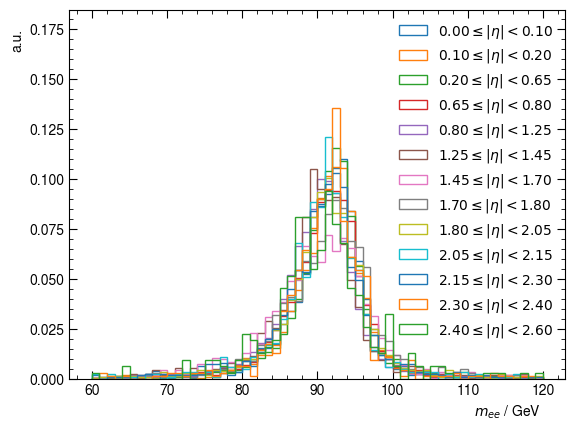

In [54]:
fig, axes = plt.subplots()
# Normalize histograms
for h in hist_mee_check:
    if(h.Integral()>0.):
        h.Scale(1 / h.Integral())
    else:
        print(h.GetTitle(), 'has no events!')

fpu.hist_line(*hist_mee_check, axes=axes)
plt.xlabel("$m_{ee}$ / GeV", ha='right', x=0.95)
plt.ylabel("a.u.", ha='right', y=0.95)
atlasify(False)
plt.savefig("plots/m_ee_binned_check.pdf")

**Assignment:** Perform the fit in every $\eta$ bin with the calibrated events. Have the results improved?

Ecorr=  91.14051529754734 +- 1.2687754159571438  MeV, tval =  0.037110352124173906


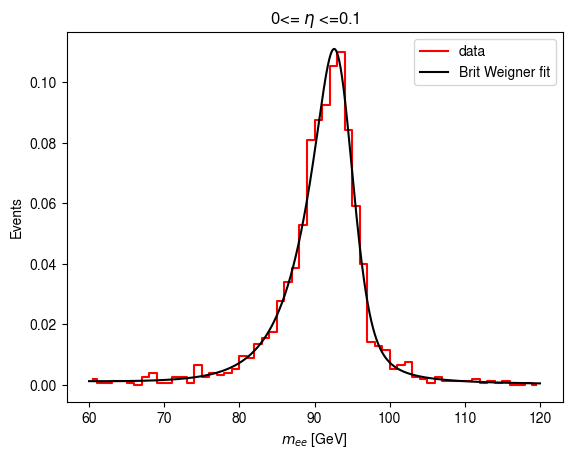

Ecorr=  91.36306207349915 +- 3.4714407114420673  MeV, tval =  0.05054445346590959


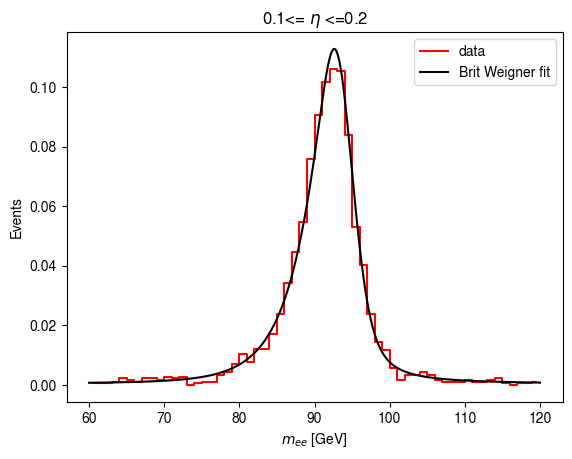

Ecorr=  91.46799753240174 +- 3.3997581675094604  MeV, tval =  0.0824757287390076


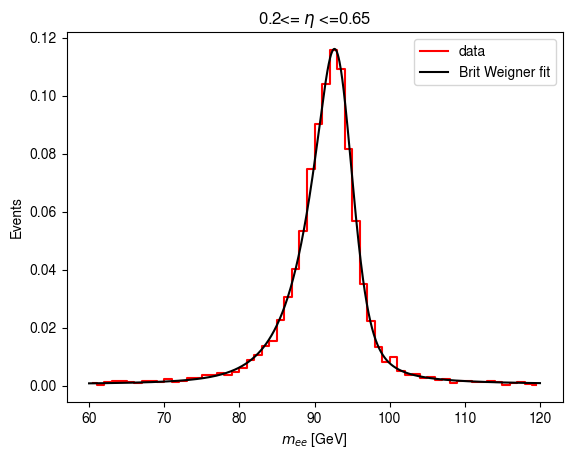

Ecorr=  91.0114424640209 +- 3.648315483827102  MeV, tval =  0.048284622522367725


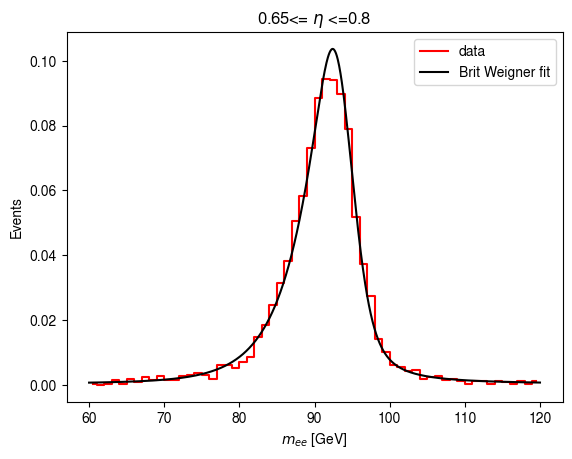

Ecorr=  90.28330995904876 +- 0.9119915629757819  MeV, tval =  0.9915552705340674


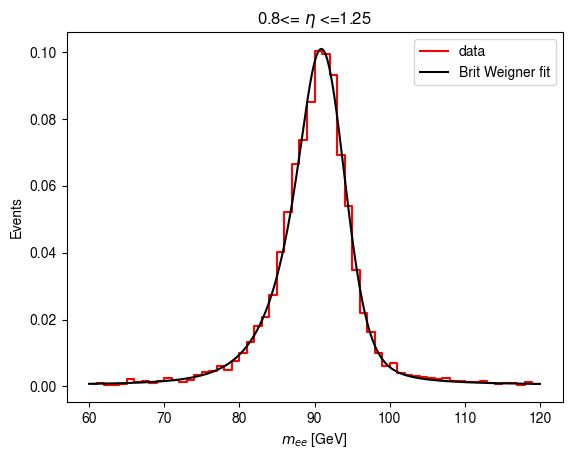

Ecorr=  90.01859163210909 +- 0.12178407599481286  MeV, tval =  9.5990248178317


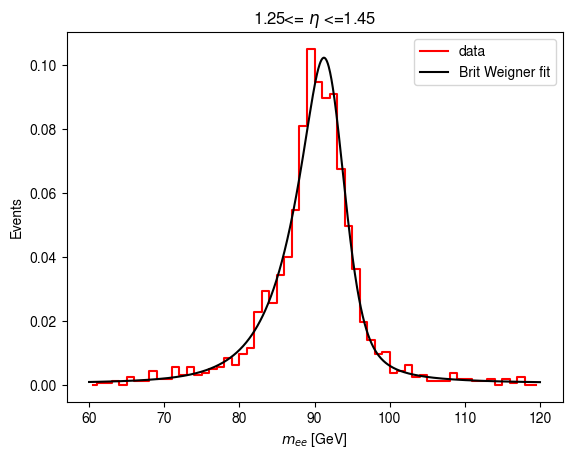

Ecorr=  89.42570770694371 +- 1.901542669175508  MeV, tval =  0.9265594307280165


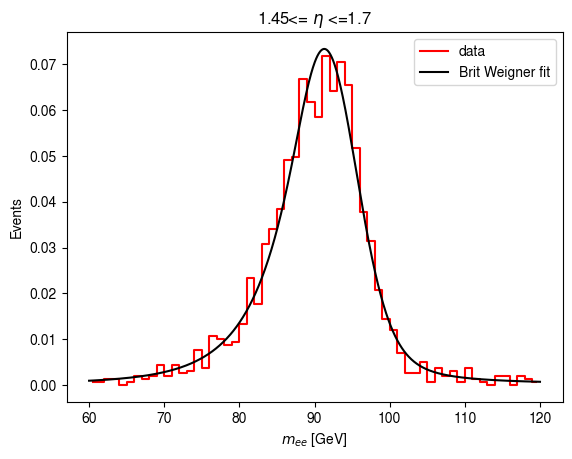

Ecorr=  91.5515189106215 +- 3.686805404531634  MeV, tval =  0.09870846727472575


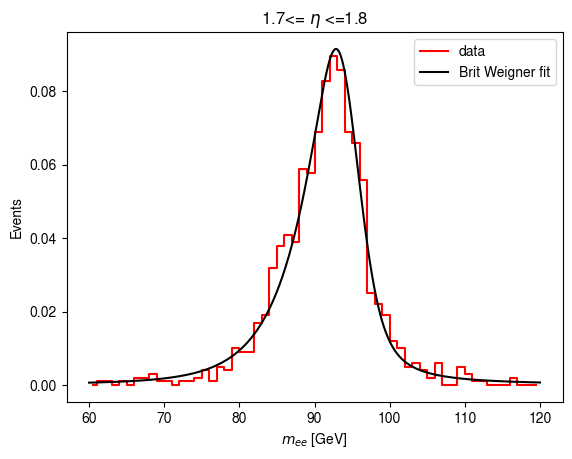

Ecorr=  90.97697555693458 +- 1.3353715036791824  MeV, tval =  0.15772722608286902


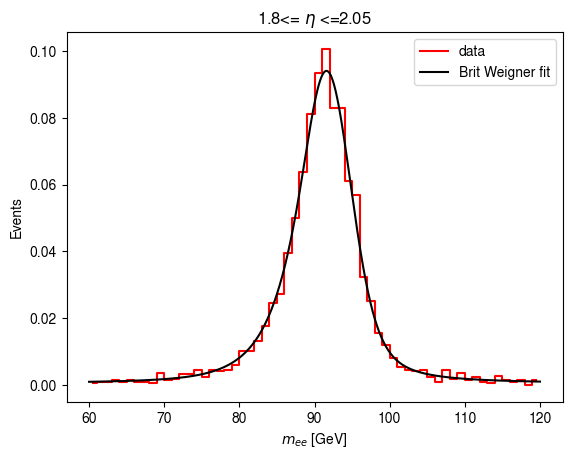

Ecorr=  90.78638037585523 +- 3.485442915141079  MeV, tval =  0.11511295233149228


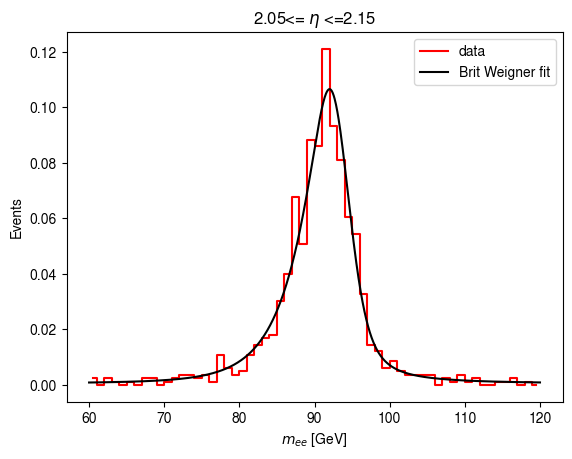

Ecorr=  90.79134958034346 +- 0.1882030733201545  MeV, tval =  2.105440749006647


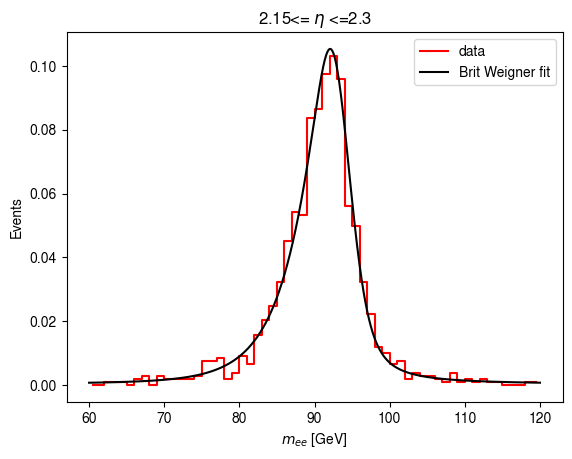

Ecorr=  91.18861977443521 +- 0.1150619780313435  MeV, tval =  0.008862827257577328


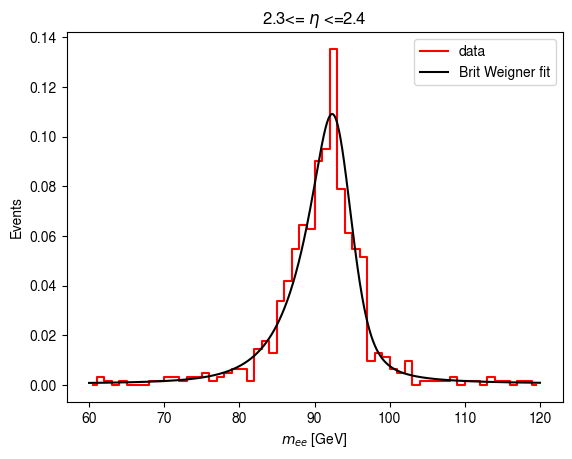

Ecorr=  89.903030492474 +- 3.3464695488335163  MeV, tval =  0.38385811936456


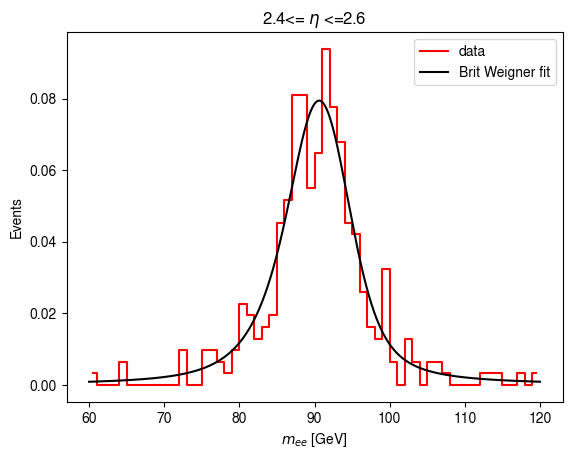

[#1] INFO:DataHandling -- RooDataHist::adjustBinning(data): fit range of variable x expanded to nearest bin boundaries: [0,200] --> [60,120]
[#0] WARNING:InputArguments -- The parameter 'widthBW' with range [0, 10] of the RooBreitWigner 'BreitWigner' exceeds the safe range of (0, inf). Advise to limit its range.
[#1] INFO:Caching -- Changing internal binning of variable 'x' in FFT 'ZeeModel' from 100 to 930 to improve the precision of the numerical FFT. This can be done manually by setting an additional binning named 'cache'.
[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Eval -- RooRealVar::setRange(x) new range named 'refrange_fft_ZeeModel' created with bounds [60,120]
[#1] INFO:Caching -- RooAbsCachedPdf::getCache(ZeeModel) creating new cache 0x6463ae75f040 with pdf BreitWigner_CONV_CBshape_CACHE_Obs[x]_NORM_x for nset (x) with code 0 from preexisting content.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing n

In [57]:


for i, hist in enumerate(hist_mee_check):
    n_bins = hist.GetNbinsX()

    model = fpu.ZeeModel(hist, 0, 200)
    res = model.fit_to_data()
    params = model.model.getParameters(model.data)

    param_dict = {}

    for var in params: 
        param_dict[var.GetName()] = {
            "value": var.getVal(),
            "error": var.getError(),
        }
    param_list = []
    for name, info in param_dict.items():
        if name == "meanBW":
            print('Ecorr= ', info['value'],'+-', info['error'] , ' MeV, tval = ', str(abs(info['value']-m_Z)/info['error']))

    bin_centers = []
    bin_contents = []

    for b in range(1, n_bins + 1):
        bin_centers.append(hist.GetBinCenter(b))
        bin_contents.append(hist.GetBinContent(b))

    bin_centers = np.array(bin_centers)
    bin_contents = np.array(bin_contents)

    x_vals = np.linspace(60, 120, 1000)
    y_vals = []

    for x in x_vals:
        model.x.setVal(x)
        y_vals.append(model.model.getVal(ROOT.RooArgSet(model.x)))

    y_vals = np.array(y_vals)

    y_vals *= sum(bin_contents) * (bin_centers[1] - bin_centers[0])

    plt.figure()

    plt.step(bin_centers, bin_contents, where='mid', label='data', color='red')
    plt.plot(x_vals, y_vals, label="Brit Weigner fit", color='black')

    plt.title(str(round(eta_edges[i],2))+r'<= $\eta$ <='+ str(round(eta_edges[i+1],2)))
    plt.xlabel(r"$m_{ee}$ [GeV]")
    plt.ylabel("Events")
    plt.legend()

    plt.show()